0. import the libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import time

1. data preprocessing

1.1 Preprocess the weather data

In [ ]:
weather_df = pd.read_csv('combined_weather_data.csv')
weather_df.head()

,airport_code,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),snowfall_sum (cm),wind_direction_10m_dominant (°),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),daylight_duration (s),weather_code (wmo code),surface_pressure_mean (hPa),surface_pressure_max (hPa),surface_pressure_min (hPa),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h)
0,FAI,2022-01-01,-26.2,-23.5,-27.9,0.2,0.07,344,10.9,21.6,14626.94,71,1001.8,1014.8,989.6,17.6,8.9,12.6,6.1
1,FAI,2022-01-02,-30.0,-28.2,-32.1,0.0,0.00,18,11.6,19.8,14832.31,1,1022.2,1024.6,1015.8,16.2,9.3,12.6,7.8
2,FAI,2022-01-03,-30.7,-28.3,-32.4,0.0,0.00,51,17.3,33.1,15052.90,0,1022.7,1024.2,1021.0,23.9,13.3,17.3,10.5
3,FAI,2022-01-04,-29.1,-25.6,-32.9,0.0,0.00,73,15.1,26.6,15290.01,0,1023.1,1024.1,1022.2,17.7,11.2,12.6,7.6
4,FAI,2022-01-05,-33.2,-29.5,-35.4,0.0,0.00,40,14.3,16.9,15542.44,0,1018.0,1022.4,1012.6,14.2,11.3,11.5,7.4


In [ ]:
weather_df.dtypes

airport_code                        object
time                                object
temperature_2m_mean (°C)           float64
temperature_2m_max (°C)            float64
temperature_2m_min (°C)            float64
precipitation_sum (mm)             float64
snowfall_sum (cm)                  float64
wind_direction_10m_dominant (°)      int64
wind_speed_10m_max (km/h)          float64
wind_gusts_10m_max (km/h)          float64
daylight_duration (s)              float64
weather_code (wmo code)              int64
surface_pressure_mean (hPa)        float64
surface_pressure_max (hPa)         float64
surface_pressure_min (hPa)         float64
wind_gusts_10m_mean (km/h)         float64
wind_speed_10m_mean (km/h)         float64
wind_gusts_10m_min (km/h)          float64
wind_speed_10m_min (km/h)          float64
dtype: object

In [ ]:
# group the weather codes
weather_code_groups = {
    'clear': [0],  # Clear sky
    'cloudy': [1, 2, 3, 4],  # Various degrees of cloudiness

    # Visibility Issues
    'fog': [45, 48],  # Fog, depositing rime fog
    'haze_dust_smoke': [40, 41, 42],  # Not standard WMO but sometimes used in datasets

    # Light Precipitation
    'drizzle': [51, 53, 55],  # Light to heavy drizzle
    'freezing_drizzle': [56, 57],

    # Rain
    'light_rain': [61],
    'moderate_rain': [63],
    'heavy_rain': [65],
    'freezing_rain': [66, 67],

    # Snow
    'light_snow': [71],
    'moderate_snow': [73],
    'heavy_snow': [75],
    'snow_grains': [77],
    'snow_showers': [85, 86],

    # Thunderstorm
    'thunderstorm': [95],  # Thunderstorm without hail
    'severe_thunderstorm': [96, 99],  # With hail

    # Showers
    'rain_showers': [80, 81, 82],
    'snow_showers': [83, 84],

    # Dust/Sand Storms
    'dust_storm': [30, 31, 32],
    'sandstorm': [33, 34, 35],
}

# convert the groups to weather flags
def assign_weather_flags(weather_df, col='weather_code (wmo code)'):
    for group, codes in weather_code_groups.items():
        weather_df[f'is_{group}'] = weather_df[col].isin(codes).astype(int)
    return weather_df
weather_df = assign_weather_flags(weather_df)


In [ ]:
# select the flight influencing groups and convert to hazard flags
hazardous_conditions = [
    'fog', 'freezing_rain', 'freezing_drizzle', 'heavy_rain', 
    'heavy_snow', 'thunderstorm', 'severe_thunderstorm', 
    'snow_showers', 'dust_storm', 'sandstorm'
]
weather_df['is_hazardous'] = weather_df[[f'is_{c}' for c in hazardous_conditions]].max(axis=1)

In [ ]:
# Create higher-level indicators
weather_df['is_precipitating'] = weather_df[[
    'is_drizzle', 'is_freezing_drizzle', 'is_light_rain','is_moderate_rain', 'is_heavy_rain', 
    'is_freezing_rain', 'is_light_snow', 'is_moderate_snow', 'is_heavy_snow', 'is_snow_grains', 
    'is_rain_showers', 'is_snow_showers'
]].max(axis=1)

weather_df['is_low_visibility'] = weather_df[['is_fog']].max(axis=1)

weather_df['is_thunderstorming'] = weather_df[[
    'is_thunderstorm', 'is_severe_thunderstorm'
]].max(axis=1)

weather_df['is_severe_wx'] = weather_df[[
    'is_freezing_rain', 'is_freezing_drizzle',
    'is_heavy_rain', 'is_heavy_snow', 'is_thunderstorming',
    'is_dust_storm', 'is_sandstorm', 'is_fog'
]].max(axis=1)


In [ ]:
# create wind and temperature features
weather_df['is_high_wind'] = weather_df['wind_gusts_10m_max (km/h)'] > 40
weather_df['is_cold'] = weather_df['temperature_2m_min (°C)'] < -5
weather_df['is_hot'] = weather_df['temperature_2m_max (°C)'] > 35

In [ ]:
weather_df.head()

,airport_code,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),snowfall_sum (cm),wind_direction_10m_dominant (°),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),...,is_dust_storm,is_sandstorm,is_hazardous,is_precipitating,is_low_visibility,is_thunderstorming,is_severe_wx,is_high_wind,is_cold,is_hot
0,FAI,2022-01-01,-26.2,-23.5,-27.9,0.2,0.07,344,10.9,21.6,...,0,0,0,1,0,0,0,False,True,False
1,FAI,2022-01-02,-30.0,-28.2,-32.1,0.0,0.00,18,11.6,19.8,...,0,0,0,0,0,0,0,False,True,False
2,FAI,2022-01-03,-30.7,-28.3,-32.4,0.0,0.00,51,17.3,33.1,...,0,0,0,0,0,0,0,False,True,False
3,FAI,2022-01-04,-29.1,-25.6,-32.9,0.0,0.00,73,15.1,26.6,...,0,0,0,0,0,0,0,False,True,False
4,FAI,2022-01-05,-33.2,-29.5,-35.4,0.0,0.00,40,14.3,16.9,...,0,0,0,0,0,0,0,False,True,False


In [ ]:
weather_df.columns

Index(['airport_code', 'time', 'temperature_2m_mean (°C)',
       'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'precipitation_sum (mm)', 'snowfall_sum (cm)',
       'wind_direction_10m_dominant (°)', 'wind_speed_10m_max (km/h)',
       'wind_gusts_10m_max (km/h)', 'daylight_duration (s)',
       'weather_code (wmo code)', 'surface_pressure_mean (hPa)',
       'surface_pressure_max (hPa)', 'surface_pressure_min (hPa)',
       'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)',
       'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)', 'is_clear',
       'is_cloudy', 'is_fog', 'is_haze_dust_smoke', 'is_drizzle',
       'is_freezing_drizzle', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'is_freezing_rain', 'is_light_snow',
       'is_moderate_snow', 'is_heavy_snow', 'is_snow_grains',
       'is_snow_showers', 'is_thunderstorm', 'is_severe_thunderstorm',
       'is_rain_showers', 'is_dust_storm', 'is_sandstorm', 'is_hazardous',
       'is_preci

In [ ]:
weather_df_short = weather_df[['airport_code', 'time', 'is_hazardous', 'is_precipitating', 'is_low_visibility', 'is_thunderstorming', 'is_severe_wx', 'is_high_wind', 'is_cold', 'is_hot']].copy()

  airport_code        time  is_hazardous  is_precipitating  is_low_visibility  \
0          FAI  2022-01-01             0                 1                  0   
1          FAI  2022-01-02             0                 0                  0   
2          FAI  2022-01-03             0                 0                  0   
3          FAI  2022-01-04             0                 0                  0   
4          FAI  2022-01-05             0                 0                  0   

   is_thunderstorming  is_severe_wx  is_high_wind  is_cold  is_hot  
0                   0             0         False     True   False  
1                   0             0         False     True   False  
2                   0             0         False     True   False  
3                   0             0         False     True   False  
4                   0             0         False     True   False  
airport_code          object
time                  object
is_hazardous           int64
is_precipita

In [ ]:
# change the time column to date
weather_df_short['time'] = pd.to_datetime(weather_df_short['time'])

In [ ]:
print(weather_df_short.head())
print(weather_df_short.dtypes)

  airport_code       time  is_hazardous  is_precipitating  is_low_visibility  \
0          FAI 2022-01-01             0                 1                  0   
1          FAI 2022-01-02             0                 0                  0   
2          FAI 2022-01-03             0                 0                  0   
3          FAI 2022-01-04             0                 0                  0   
4          FAI 2022-01-05             0                 0                  0   

   is_thunderstorming  is_severe_wx  is_high_wind  is_cold  is_hot  
0                   0             0         False     True   False  
1                   0             0         False     True   False  
2                   0             0         False     True   False  
3                   0             0         False     True   False  
4                   0             0         False     True   False  
airport_code                  object
time                  datetime64[ns]
is_hazardous                   

In [ ]:
# save the dataframe to a csv file
weather_df_short.to_csv('weather_features.csv', index=False)

1.2 Preprocess the flight data

In [ ]:
# load the flight data
flight_df = pd.read_csv('UA2022-2024.csv')

In [ ]:
# drop the columns that will definitely not be used in the modeling, and columns are the actual data that is unknown at prediction time
flight_df = flight_df.drop(columns=['MKT_UNIQUE_CARRIER', 'MKT_CARRIER_FL_NUM','TAIL_NUM','OP_CARRIER_FL_NUM',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_CITY_NAME', 'DEST_AIRPORT_ID', 'DEST_CITY_NAME',
       'CANCELLED', 'DIVERTED','DEP_TIME_BLK', 'ARR_TIME_BLK','DISTANCE_GROUP',
       'DEP_TIME','DEP_DELAY_NEW','ARR_TIME','CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
       'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIRCRAFT_OWNER',
       'AIRCRAFT_SEATS'])

2. feature engineering

In [ ]:
# get the month, day and week of day from the flight date
flight_df['FL_DATE'] = pd.to_datetime(flight_df['FL_DATE'])
flight_df['YEAR'] = flight_df['FL_DATE'].dt.year
flight_df['MONTH'] = flight_df['FL_DATE'].dt.month
flight_df['DAY'] = flight_df['FL_DATE'].dt.day
flight_df['WEEKDAY'] = flight_df['FL_DATE'].dt.weekday

C:\Users\向文\AppData\Local\Temp\ipykernel_14352\552379881.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_df['FL_DATE'] = pd.to_datetime(flight_df['FL_DATE'])


In [ ]:
# engineer the crs_dep_time to get the hour by dividing by 100 and getting the integer part
flight_df['CRS_DEP_TIME'] = flight_df['CRS_DEP_TIME'].astype(str).str.zfill(4).astype(int)
flight_df['CRS_DEP_TIME'] = flight_df['CRS_DEP_TIME'] // 100
# engineer the crs_arr_time to get the hour by dividing by 100 and getting the integer part
flight_df['CRS_ARR_TIME'] = flight_df['CRS_ARR_TIME'].astype(str).str.zfill(4).astype(int)
flight_df['CRS_ARR_TIME'] = flight_df['CRS_ARR_TIME'] // 100

In [ ]:
# create a new column for delay category based on , 0 for delay up to 60, 1 for delay greater than 60 and less than 360, 2 for delay greater than or equal to 360
flight_df['DELAY_CATEGORY'] = np.where(flight_df['ARR_DELAY_NEW'] <= 60, 0, np.where(flight_df['ARR_DELAY_NEW'] < 360, 1, 2))

In [ ]:
# add a column which counts the number of flights departing from the origin airport on that day
flight_df['ORIGIN_TRAFFIC'] = flight_df.groupby(['ORIGIN','FL_DATE'])['FL_DATE'].transform('count')
# add a column which counts the number of flights arriving at the destination airport on that day
flight_df['DEST_TRAFFIC'] = flight_df.groupby(['DEST','FL_DATE'])['FL_DATE'].transform('count')

In [ ]:
# check the accuracy of origin traffic and destination traffic for flight date 2022-01-01 and origin airport LAX
print(flight_df[(flight_df['FL_DATE']=='2023-01-01') & (flight_df['ORIGIN']=='LAX')][['ORIGIN_TRAFFIC']])
print(flight_df[(flight_df['FL_DATE']=='2023-01-01') & (flight_df['DEST']=='LAX')][['DEST_TRAFFIC']])

         ORIGIN_TRAFFIC
1643369              91
1643375              91
1643381              91
1643400              91
1643410              91
...                 ...
1646229              91
1646230              91
1646264              91
1646285              91
1646347              91

[91 rows x 1 columns]
         DEST_TRAFFIC
1643393            89
1643399            89
1643405            89
1643408            89
1643424            89
...               ...
1646198            89
1646211            89
1646249            89
1646265            89
1646286            89

[89 rows x 1 columns]


In [ ]:
print(flight_df.head())
print(flight_df.columns)

     FL_DATE ORIGIN DEST  CRS_DEP_TIME  CRS_ARR_TIME  ARR_DELAY_NEW  DISTANCE  \
0 2022-01-01    LAX  ITO            18            22            0.0    2449.0   
1 2022-01-01    RDU  DEN            15            17          222.0    1436.0   
2 2022-01-01    SFO  SEA            12            15           43.0     679.0   
3 2022-01-01    PHX  IAH             5             8            0.0    1009.0   
4 2022-01-01    EWR  RDU            21            23          126.0     416.0   

   YEAR  MONTH  DAY  WEEKDAY  DELAY_CATEGORY  ORIGIN_TRAFFIC  DEST_TRAFFIC  
0  2022      1    1        5               0              84             1  
1  2022      1    1        5               1              13           303  
2  2022      1    1        5               0             151            17  
3  2022      1    1        5               0              19           265  
4  2022      1    1        5               1             228            14  
Index(['FL_DATE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME',

In [ ]:
# save the transformed flight data to a new csv file
flight_df.to_csv('UA2022-2024_flight_data_transformed.csv', index=False)

In [ ]:
# left join the flight data and weather data on the origin airport code and date
flight_weather_df1 = flight_df.merge(weather_df_short, how='left', left_on=['ORIGIN', 'FL_DATE'], right_on=['airport_code', 'time'])
flight_weather_df1 = flight_weather_df1.drop(columns=['airport_code', 'time'])


In [ ]:
# rename the columns 'is_hazardous', 'is_precipitating', 'is_low_visibility', 'is_thunderstorming','is_severe_wx', 'is_high_wind', 'is_cold', 'is_hot' to 'origin_is_hazardous', 'origin_is_precipitating', 'origin_is_low_visibility', 'origin_is_thunderstorming','origin_is_severe_wx', 'origin_is_high_wind', 'origin_is_cold', 'origin_is_hot'
flight_weather_df1 = flight_weather_df1.rename(columns={
    'is_hazardous': 'origin_is_hazardous',
    'is_precipitating': 'origin_is_precipitating',
    'is_low_visibility': 'origin_is_low_visibility',
    'is_thunderstorming': 'origin_is_thunderstorming',
    'is_severe_wx': 'origin_is_severe_wx',
    'is_high_wind': 'origin_is_high_wind',
    'is_cold': 'origin_is_cold',
    'is_hot': 'origin_is_hot'
})

In [ ]:
# left join the flight data and weather data on the destination airport code and date, but there is a condition with time. If CRS_DEP_TIME>CRS_ARR_TIME, FL_DATE+1, else FL_DATE
# generate a new column 'FL_DATE_DEST' which is the same as FL_DATE, but if CRS_DEP_TIME>CRS_ARR_TIME, add 1 day to FL_DATE
flight_weather_df1['FL_DATE_DEST'] = flight_weather_df1.apply(
    lambda row: row['FL_DATE'] + pd.Timedelta(days=1) if row['CRS_DEP_TIME'] > row['CRS_ARR_TIME'] else row['FL_DATE'],
    axis=1
)
# left join the flight data and weather data on the destination airport code and date
flight_weather_df1 = flight_weather_df1.merge(weather_df_short, how='left', left_on=['DEST', 'FL_DATE_DEST'], right_on=['airport_code', 'time'])


In [ ]:
# rename the columns 'is_hazardous', 'is_precipitating', 'is_low_visibility', 'is_thunderstorming','is_severe_wx', 'is_high_wind', 'is_cold', 'is_hot' to 'dest_is_hazardous', 'dest_is_precipitating', 'dest_is_low_visibility', 'dest_is_thunderstorming','dest_is_severe_wx', 'dest_is_high_wind', 'dest_is_cold', 'dest_is_hot'
flight_weather_df1 = flight_weather_df1.rename(columns={
    'is_hazardous': 'dest_is_hazardous',
    'is_precipitating': 'dest_is_precipitating',
    'is_low_visibility': 'dest_is_low_visibility',
    'is_thunderstorming': 'dest_is_thunderstorming',
    'is_severe_wx': 'dest_is_severe_wx',
    'is_high_wind': 'dest_is_high_wind',
    'is_cold': 'dest_is_cold',
    'is_hot': 'dest_is_hot'
})

In [ ]:
# drop the 'FL_DATE_DEST', 'airport_code', 'time' columns
flight_weather_df1 = flight_weather_df1.drop(columns=[ 'FL_DATE_DEST', 'airport_code', 'time'])

In [ ]:
# check the null values in the dataframe
print(flight_weather_df1.isnull().sum())

FL_DATE                        0
ORIGIN                         0
DEST                           0
CRS_DEP_TIME                   0
CRS_ARR_TIME                   0
ARR_DELAY_NEW                  0
DISTANCE                       0
YEAR                           0
MONTH                          0
DAY                            0
WEEKDAY                        0
DELAY_CATEGORY                 0
ORIGIN_TRAFFIC                 0
DEST_TRAFFIC                   0
origin_is_hazardous           37
origin_is_precipitating       37
origin_is_low_visibility      37
origin_is_thunderstorming     37
origin_is_severe_wx           37
origin_is_high_wind           37
origin_is_cold                37
origin_is_hot                 37
dest_is_hazardous            135
dest_is_precipitating        135
dest_is_low_visibility       135
dest_is_thunderstorming      135
dest_is_severe_wx            135
dest_is_high_wind            135
dest_is_cold                 135
dest_is_hot                  135
dtype: int

In [ ]:
# save the flight weather data to a new csv file
flight_weather_df1.to_csv('UA2022-2024_flight_weather_data_with_nulls.csv', index=False)

In [2]:
# read the flight weather data with nulls
flight_weather_df = pd.read_csv('UA2022-2024_flight_weather_data_with_nulls.csv')

C:\Users\向文\AppData\Local\Temp\ipykernel_12976\3508776322.py:2: DtypeWarning: Columns (19,20,21,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  flight_weather_df = pd.read_csv('UA2022-2024_flight_weather_data_with_nulls.csv')


In [4]:
# check the null records in the dataframe
flight_weather_df[flight_weather_df.isnull().any(axis=1)].to_csv('null_weather_records.csv', index=False)

In [3]:
# drop the null records in the dataframe
flight_weather_df = flight_weather_df.dropna()
# check the null records in the dataframe
flight_weather_df.isnull().sum()

FL_DATE                      0
ORIGIN                       0
DEST                         0
CRS_DEP_TIME                 0
CRS_ARR_TIME                 0
ARR_DELAY_NEW                0
DISTANCE                     0
YEAR                         0
MONTH                        0
DAY                          0
WEEKDAY                      0
DELAY_CATEGORY               0
ORIGIN_TRAFFIC               0
DEST_TRAFFIC                 0
origin_is_hazardous          0
origin_is_precipitating      0
origin_is_low_visibility     0
origin_is_thunderstorming    0
origin_is_severe_wx          0
origin_is_high_wind          0
origin_is_cold               0
origin_is_hot                0
dest_is_hazardous            0
dest_is_precipitating        0
dest_is_low_visibility       0
dest_is_thunderstorming      0
dest_is_severe_wx            0
dest_is_high_wind            0
dest_is_cold                 0
dest_is_hot                  0
dtype: int64

In [ ]:
# save the flight weather data to a new csv file
flight_weather_df.to_csv('UA2022-2024_flight_weather_data.csv', index=False)

In [4]:
flight_weather_df = pd.read_csv('UA2022-2024_flight_weather_data.csv')

In [18]:
flight_weather_df.columns

Index(['FL_DATE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME',
       'ARR_DELAY_NEW', 'DISTANCE', 'YEAR', 'MONTH', 'DAY', 'WEEKDAY',
       'DELAY_CATEGORY', 'ORIGIN_TRAFFIC', 'DEST_TRAFFIC',
       'origin_is_hazardous', 'origin_is_precipitating',
       'origin_is_low_visibility', 'origin_is_thunderstorming',
       'origin_is_severe_wx', 'origin_is_high_wind', 'origin_is_cold',
       'origin_is_hot', 'dest_is_hazardous', 'dest_is_precipitating',
       'dest_is_low_visibility', 'dest_is_thunderstorming',
       'dest_is_severe_wx', 'dest_is_high_wind', 'dest_is_cold',
       'dest_is_hot'],
      dtype='object')

In [5]:
# drop the intermediate columns that are not needed for modeling
flight_weather_df = flight_weather_df.drop(columns=['FL_DATE', 'ARR_DELAY_NEW'])

In [6]:
# check the delay category counts
print(flight_weather_df['DELAY_CATEGORY'].value_counts())
# check the data types of the dataframe
print(flight_weather_df.dtypes)

DELAY_CATEGORY
0    3558459
1     262353
2      13969
Name: count, dtype: int64
ORIGIN                        object
DEST                          object
CRS_DEP_TIME                   int64
CRS_ARR_TIME                   int64
DISTANCE                     float64
YEAR                           int64
MONTH                          int64
DAY                            int64
WEEKDAY                        int64
DELAY_CATEGORY                 int64
ORIGIN_TRAFFIC                 int64
DEST_TRAFFIC                   int64
origin_is_hazardous          float64
origin_is_precipitating      float64
origin_is_low_visibility     float64
origin_is_thunderstorming    float64
origin_is_severe_wx          float64
origin_is_high_wind             bool
origin_is_cold                  bool
origin_is_hot                   bool
dest_is_hazardous            float64
dest_is_precipitating        float64
dest_is_low_visibility       float64
dest_is_thunderstorming      float64
dest_is_severe_wx            flo

In [7]:
# convert every feature that comes after DEST_TRAFFIC to int
for col in flight_weather_df.columns[flight_weather_df.columns.get_loc('DEST_TRAFFIC')+1:]:
    flight_weather_df[col] = flight_weather_df[col].astype(int)
# check the data types of the dataframe again
print(flight_weather_df.dtypes)


ORIGIN                        object
DEST                          object
CRS_DEP_TIME                   int64
CRS_ARR_TIME                   int64
DISTANCE                     float64
YEAR                           int64
MONTH                          int64
DAY                            int64
WEEKDAY                        int64
DELAY_CATEGORY                 int64
ORIGIN_TRAFFIC                 int64
DEST_TRAFFIC                   int64
origin_is_hazardous            int64
origin_is_precipitating        int64
origin_is_low_visibility       int64
origin_is_thunderstorming      int64
origin_is_severe_wx            int64
origin_is_high_wind            int64
origin_is_cold                 int64
origin_is_hot                  int64
dest_is_hazardous              int64
dest_is_precipitating          int64
dest_is_low_visibility         int64
dest_is_thunderstorming        int64
dest_is_severe_wx              int64
dest_is_high_wind              int64
dest_is_cold                   int64
d

3. modeling data preparation

In [8]:
# balance the dataset using undersampling and oversampling
flight_weather_df_0 = flight_weather_df[flight_weather_df['DELAY_CATEGORY']==0]
flight_weather_df_1 = flight_weather_df[flight_weather_df['DELAY_CATEGORY']==1]
flight_weather_df_2 = flight_weather_df[flight_weather_df['DELAY_CATEGORY']==2]
# sample the 0 category to the size of the 1 category
flight_weather_df_0 = flight_weather_df_0.sample(n=len(flight_weather_df_1))
# sample the 2 category to the size of the 1 category by over sampling
flight_weather_df_2 = flight_weather_df_2.sample(n=len(flight_weather_df_1), replace=True)
# concatenate all 3 categories
flight_weather_df_balanced = pd.concat([flight_weather_df_0, flight_weather_df_1, flight_weather_df_2])
# check the delay category counts
print(flight_weather_df_balanced['DELAY_CATEGORY'].value_counts())

DELAY_CATEGORY
0    262353
1    262353
2    262353
Name: count, dtype: int64


In [9]:
# one-hot encode the categorical columns
flight_weather_df_balanced_encoded = pd.get_dummies(flight_weather_df_balanced, columns=['ORIGIN', 'DEST'], drop_first=True)

In [10]:
# prepare predictor and target variable
X = flight_weather_df_balanced_encoded.drop(columns=['DELAY_CATEGORY'])
y = flight_weather_df_balanced_encoded['DELAY_CATEGORY']
# Convert sparse target (if it exists) to dense format
if hasattr(y, 'toarray'):
    y_dense = y.toarray()  # Convert sparse to dense format
else:
    y_dense = y  # If already dense, no conversion needed

4. create a model using Random Forest Classifier

In [11]:
# create a random forest classifier
rf = RandomForestClassifier()

5. fit training data to model and predict testing data

In [12]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_dense, test_size=0.2, random_state=42)
# fit the classifier to the training data
rf.fit(X_train, y_train)
# predict the delay category on the testing data
y_pred = rf.predict(X_test)

6. check model performance and feature importance

In [14]:
# calculate the accuracy, precision, recall and f1 scores for the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy: {}, Precision: {}, Recall: {}, F1: {}".format(accuracy, precision, recall, f1))

Accuracy: 0.7764147587223338, Precision: 0.7752204622093486, Recall: 0.7764147587223338, F1: 0.7754211133337132


C:\Users\向文\AppData\Local\Temp\ipykernel_12976\517723009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf.feature_importances_[indices][:top_n], y=X.columns[indices][:top_n], palette="viridis")


Text(0.5, 1.0, 'Top 10 Features Importance')

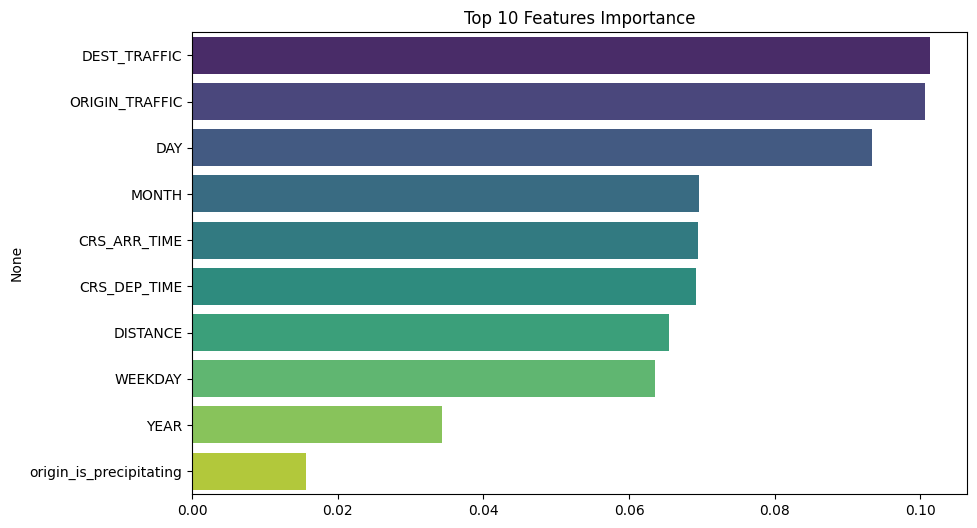

In [15]:
# plot the top 10 features
indices = np.argsort(rf.feature_importances_)[::-1]
plt.figure(figsize=(10, 6))
top_n = 10
sns.barplot(x=rf.feature_importances_[indices][:top_n], y=X.columns[indices][:top_n], palette="viridis")
plt.title("Top 10 Features Importance")


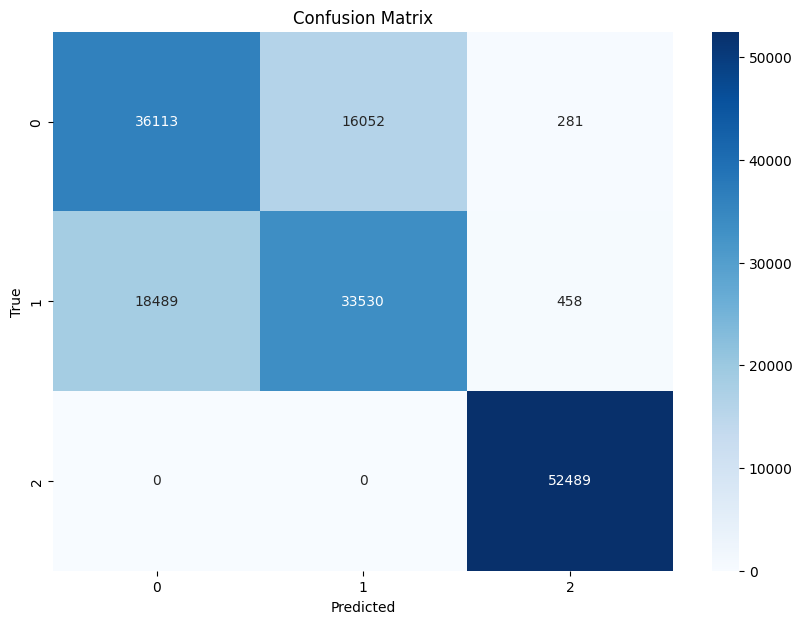

In [ ]:
# print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.69      0.68     52446
           1       0.68      0.64      0.66     52477
           2       0.99      1.00      0.99     52489

    accuracy                           0.78    157412
   macro avg       0.78      0.78      0.78    157412
weighted avg       0.78      0.78      0.78    157412



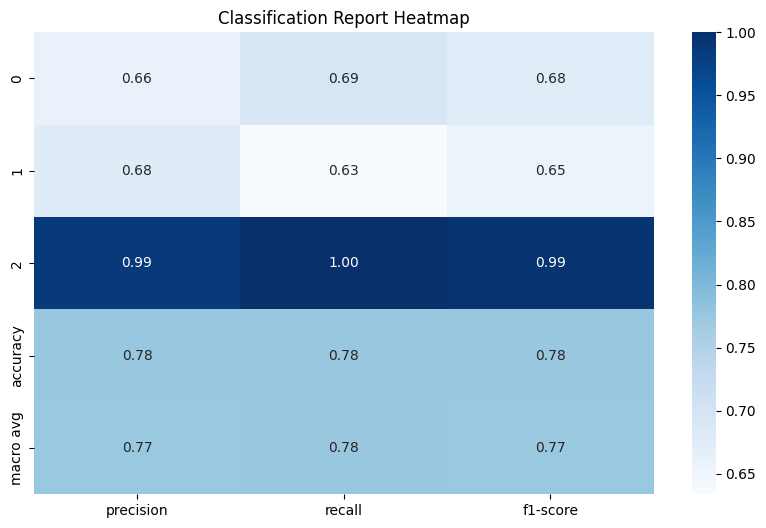

In [27]:
# Get report as dict
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

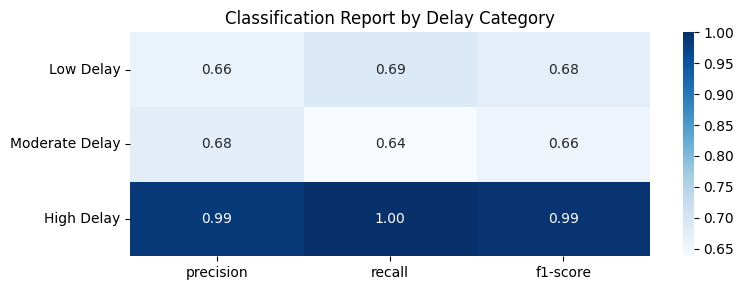

In [17]:
# modified classification report heatmap

# Generate report and convert to DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

# Define label names and extract relevant metrics only
class_names = {'0': 'Low Delay', '1': 'Moderate Delay', '2': 'High Delay'}
selected = df.loc[['0', '1', '2'], ['precision', 'recall', 'f1-score']]
selected.index = [class_names[i] for i in selected.index]

# Plot heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(selected, annot=True, fmt=".2f", cmap="Blues")
plt.title("Classification Report by Delay Category")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Haven't executed

7. Retrain the model on full data and save the model for future prediction

In [ ]:
# Retrain using full X and y
flight_model = RandomForestClassifier(random_state=42)
flight_model.fit(X, y)  # X and y are the full dataset

In [ ]:
# Save the model
import joblib
joblib.dump(flight_model, 'flight_rf_model.joblib')

In [ ]:
import joblib

# Load the trained model
model = joblib.load('flight_rf_model.joblib')

In [ ]:
# read and transform the new data


In [ ]:
# predict the delay category on the new data
predictions = model.predict(X_new)

# If you want probabilities:
probs = model.predict_proba(X_new)